# Cognifyz Machine Learning Internship

## Task 1 — Predict Restaurant Ratings

### Objective

Build a machine learning regression model to predict the
aggregate rating of a restaurant based on relevant restaurant
features.

### Approach

1. Load the cleaned rated-restaurant dataset.
2. Define the target variable.
3. Select relevant predictive features.
4. Perform feature engineering.
5. Split the dataset into training and testing sets.
6. Build a preprocessing pipeline.
7. Prepare the data for regression models.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv("../outputs/results/rated_restaurants.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7403, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
print("Minimum rating:", df["Aggregate rating"].min())
print("Maximum rating:", df["Aggregate rating"].max())
print("Zero ratings:", (df["Aggregate rating"] == 0).sum())

Minimum rating: 1.8
Maximum rating: 4.9
Zero ratings: 0


In [4]:
y = df["Aggregate rating"]

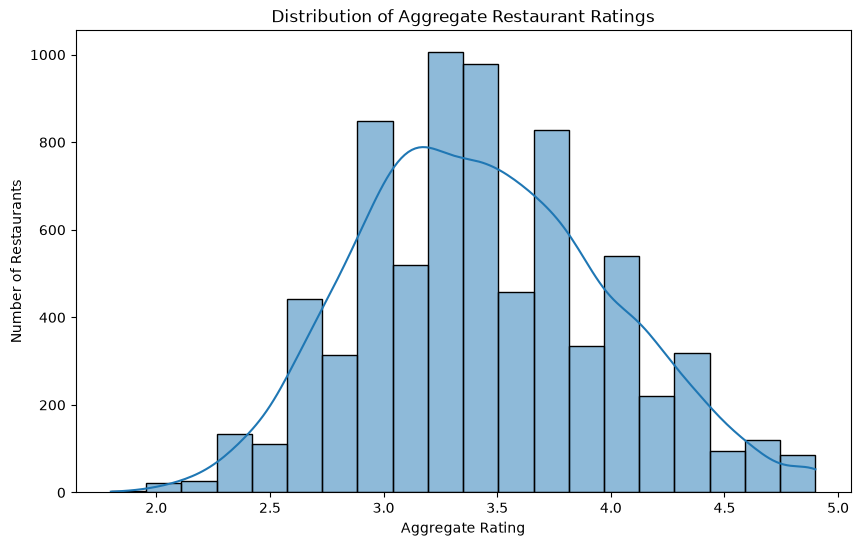

In [5]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Aggregate rating",
    bins=20,
    kde=True
)

plt.title("Distribution of Aggregate Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.savefig(
    "../outputs/figures/task1_rating_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [6]:
df["Primary Cuisine"] = (
    df["Cuisines"]
    .fillna("Unknown")
    .str.split(",")
    .str[0]
    .str.strip()
)

In [7]:
df[
    ["Cuisines", "Primary Cuisine"]
].head(20)

,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese
5,Chinese,Chinese
6,"Asian, European",Asian
7,"Seafood, Filipino, Asian, European",Seafood
8,"European, Asian, Indian",European
9,Filipino,Filipino


In [8]:
print(
    "Unique primary cuisines:",
    df["Primary Cuisine"].nunique()
)

Unique primary cuisines: 119


In [9]:
features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Latitude",
    "Longitude",
    "Country Code",
    "City",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Primary Cuisine"
]

target = "Aggregate rating"

In [10]:
X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7403, 11)
y shape: (7403,)


In [11]:
X.head()

,Average Cost for two,Price range,Votes,Latitude,Longitude,Country Code,City,Has Table booking,Has Online delivery,Is delivering now,Primary Cuisine
0,1100,3,314,14.565443,121.027535,162,Makati City,Yes,No,No,French
1,1200,3,591,14.553708,121.014101,162,Makati City,Yes,No,No,Japanese
2,4000,4,270,14.581404,121.056831,162,Mandaluyong City,Yes,No,No,Seafood
3,1500,4,365,14.585318,121.056475,162,Mandaluyong City,No,No,No,Japanese
4,1500,4,229,14.584450,121.057508,162,Mandaluyong City,Yes,No,No,Japanese


In [12]:
y.head()

0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64

In [13]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7403 entries, 0 to 7402
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Average Cost for two  7403 non-null   int64  
 1   Price range           7403 non-null   int64  
 2   Votes                 7403 non-null   int64  
 3   Latitude              7403 non-null   float64
 4   Longitude             7403 non-null   float64
 5   Country Code          7403 non-null   int64  
 6   City                  7403 non-null   str    
 7   Has Table booking     7403 non-null   str    
 8   Has Online delivery   7403 non-null   str    
 9   Is delivering now     7403 non-null   str    
 10  Primary Cuisine       7403 non-null   object 
dtypes: float64(2), int64(4), object(1), str(4)
memory usage: 636.3+ KB


In [14]:
X.isnull().sum()

Average Cost for two    0
Price range             0
Votes                   0
Latitude                0
Longitude               0
Country Code            0
City                    0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Primary Cuisine         0
dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5922
Testing samples: 1481


In [17]:
numeric_features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Latitude",
    "Longitude"
]

categorical_features = [
    "Country Code",
    "City",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Primary Cuisine"
]

In [18]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Average Cost for two', 'Price range', 'Votes', 'Latitude', 'Longitude']
Categorical features: ['Country Code', 'City', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Primary Cuisine']


In [19]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [20]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [22]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [23]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5922, 11)
Processed training shape: (5922, 278)
Original testing shape: (1481, 11)
Processed testing shape: (1481, 278)


In [24]:
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 65142 stored elements and shape (5922, 278)>

In [25]:
preprocessor.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16283 stored elements and shape (1481, 278)>

In [26]:
preprocessor.fit_transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16291 stored elements and shape (1481, 193)>

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [29]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Average Cost for two','Price range','Votes',...,'Has Online delivery', 'Is delivering now','Primary Cuisine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [30]:
y_pred = linear_model.predict(X_test)

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [32]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Baseline")
print("---------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Baseline
---------------------------
MAE : 0.30360507099203937
MSE : 0.1506301876872599
RMSE: 0.3881110507152043
R²  : 0.5129657875377254


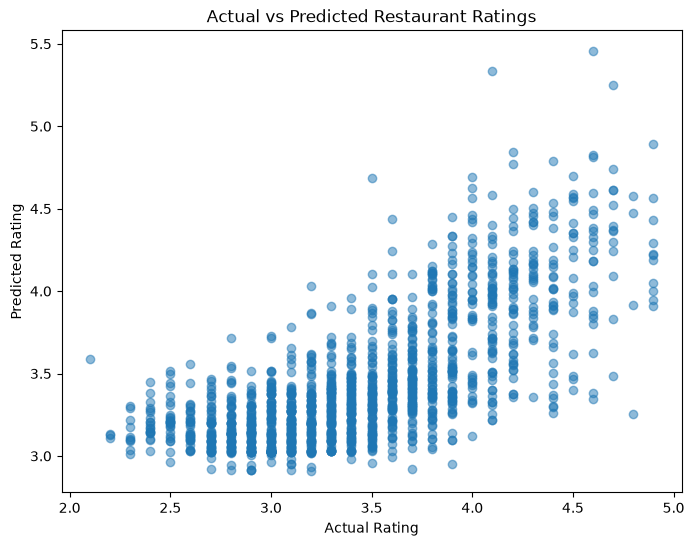

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")

plt.savefig(
    "../outputs/figures/task1_actual_vs_predicted_linear.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

# Baseline Model — Linear Regression

A Linear Regression model was selected as the baseline regression model.

The preprocessing pipeline performs:

- Median imputation for numerical missing values
- Standardization of numerical features
- Most-frequent imputation for categorical variables
- One-hot encoding of categorical variables

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² score